# 02 — Preliminary EDA

Purpose:
- Load `data/processed/eu_master_plus.csv`
- Create proposal-ready preliminary figures
- Explore EU trends, country trajectories, spending priorities, tradeoffs, and correlations

This notebook should not clean raw data. It starts from the processed master dataset.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DIR, FIGURES_DIR

plt.rcParams["figure.dpi"] = 120

print("Processed data folder:", PROCESSED_DIR)
print("Figures folder:", FIGURES_DIR)

Processed data folder: C:\Users\gilad\Documents\Data Analytics course 02_26\capstone-eu-structural-tradeoffs\data\processed
Figures folder: C:\Users\gilad\Documents\Data Analytics course 02_26\capstone-eu-structural-tradeoffs\reports\figures


## 1. Load Final Master Dataset

In [2]:
eu_master_plus = pd.read_csv(PROCESSED_DIR / "eu_master_plus.csv")

print("Shape:", eu_master_plus.shape)
print("Countries:", eu_master_plus["country"].nunique())
print("Years:", eu_master_plus["year"].min(), "-", eu_master_plus["year"].max())

display(eu_master_plus.head())
display(eu_master_plus.isna().sum().sort_values(ascending=False))

Shape: (324, 21)
Countries: 27
Years: 2014 - 2025


,country,year,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,...,debt,defense_spending,economic_affairs_spending,fuel_energy_spending,communication_spending,environment_spending,health_spending,education_spending,social_protection_spending,total_gov_expenditure
0,AT,2014,0.8,1.5,6.0,27.6,79.7,3.11,3.6,33.550,...,85.2,0.6,7.0,0.2,0.0,0.4,8.2,5.0,21.4,52.4
1,AT,2015,1.3,0.8,6.1,27.2,80.4,3.07,4.0,33.497,...,85.6,0.6,6.0,0.3,0.0,0.4,8.3,5.0,21.3,51.2
2,AT,2016,2.1,1.0,6.5,27.2,80.4,3.13,4.2,33.370,...,83.4,0.6,5.9,0.3,0.1,0.4,8.3,4.9,21.1,50.6
3,AT,2017,2.3,2.2,5.9,27.9,80.7,3.07,4.4,33.136,...,79.1,0.6,6.1,0.3,0.1,0.4,8.3,4.9,20.7,49.8
4,AT,2018,2.5,2.1,5.2,26.8,81.1,3.11,4.5,33.784,...,74.6,0.6,6.0,0.2,0.1,0.4,8.3,4.8,20.3,49.2


country                       0
year                          0
gdp_growth                    0
inflation                     0
unemployment                  0
gini                          0
education                     0
rnd                           0
ict_specialists               0
renewables                    0
emissions                     0
debt                          0
defense_spending              0
economic_affairs_spending     0
fuel_energy_spending          0
communication_spending        0
environment_spending          0
health_spending               0
education_spending            0
social_protection_spending    0
total_gov_expenditure         0
dtype: int64

## 2. Basic Descriptive Statistics

In [3]:
display(eu_master_plus.describe().round(2))

yearly_avg = (
    eu_master_plus
    .groupby("year")
    .mean(numeric_only=True)
    .round(2)
)

display(yearly_avg)

,year,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,emissions,debt,defense_spending,economic_affairs_spending,fuel_energy_spending,communication_spending,environment_spending,health_spending,education_spending,social_protection_spending,total_gov_expenditure
count,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00
mean,2019.50,2.58,2.70,7.30,29.64,77.08,1.68,4.41,23.63,8.10,68.51,1.29,5.58,0.61,0.04,0.76,6.49,4.94,16.80,45.29
std,3.46,3.63,3.45,3.88,3.92,9.12,0.89,1.46,12.34,2.70,37.99,0.60,1.70,0.58,0.05,0.31,1.48,0.98,4.23,7.26
min,2014.00,-10.90,-1.60,2.00,20.90,43.60,0.38,1.60,4.47,3.80,8.50,0.10,2.00,0.00,0.00,0.20,2.50,2.50,7.30,20.70
25%,2016.75,0.98,0.60,5.00,26.90,74.00,0.98,3.40,15.07,6.20,41.22,0.90,4.50,0.20,0.00,0.50,5.38,4.30,13.30,40.98
50%,2019.50,2.40,1.80,6.40,29.20,79.15,1.40,4.30,20.20,7.45,60.45,1.20,5.50,0.40,0.00,0.70,6.50,4.90,16.80,45.45
75%,2022.25,4.03,3.32,8.40,32.10,83.02,2.22,5.10,30.10,9.50,88.80,1.60,6.50,0.82,0.10,0.90,7.60,5.52,20.02,50.32
max,2025.00,24.60,19.40,26.60,40.80,89.40,3.64,8.90,66.39,19.50,209.40,3.70,11.40,4.50,0.30,1.70,10.10,7.80,27.20,61.70


,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,emissions,debt,defense_spending,economic_affairs_spending,fuel_energy_spending,communication_spending,environment_spending,health_spending,education_spending,social_protection_spending,total_gov_expenditure
year,,,,,,,,,,,,,,,,,,,
2014,2.25,0.28,10.84,30.39,73.93,1.59,3.51,19.79,8.97,73.69,1.12,5.81,0.47,0.03,0.83,6.16,5.10,17.17,46.58
2015,3.67,-0.06,9.99,30.32,74.38,1.60,3.60,20.35,8.85,71.49,1.11,5.48,0.46,0.03,0.84,6.10,5.01,16.83,45.44
2016,2.60,0.13,8.99,30.14,75.11,1.54,3.77,20.43,8.89,70.63,1.15,4.69,0.45,0.02,0.70,6.01,4.86,16.73,43.69
2017,4.06,1.71,7.87,29.93,75.59,1.57,3.90,20.89,8.98,67.75,1.20,4.72,0.47,0.02,0.69,5.98,4.77,16.38,42.88
2018,3.40,1.90,6.82,29.69,76.31,1.61,4.07,21.55,8.83,65.81,1.20,5.13,0.45,0.03,0.73,6.03,4.83,16.18,43.26
2019,2.94,1.69,6.21,29.63,77.03,1.67,4.14,22.43,8.41,63.55,1.17,4.92,0.47,0.03,0.74,6.15,4.89,16.20,43.09
2020,-4.06,0.69,7.02,29.36,77.73,1.76,4.47,24.36,7.68,75.21,1.34,7.10,0.55,0.04,0.77,7.16,5.14,18.16,49.15
2021,7.42,2.84,6.64,29.40,78.40,1.74,4.77,24.82,8.00,71.88,1.26,6.54,0.52,0.04,0.75,7.25,4.93,17.00,46.92
2022,3.59,10.73,5.77,29.16,78.79,1.74,4.99,25.71,7.70,67.38,1.29,6.18,1.30,0.05,0.73,6.74,4.78,16.43,45.04


## Figure 1 — EU Normalized KPI Trends

Normalized EU-average structural indicators over time, highlighting sustainability transition, innovation growth, COVID-19 fiscal shock, and post-2021 inflation dynamics.

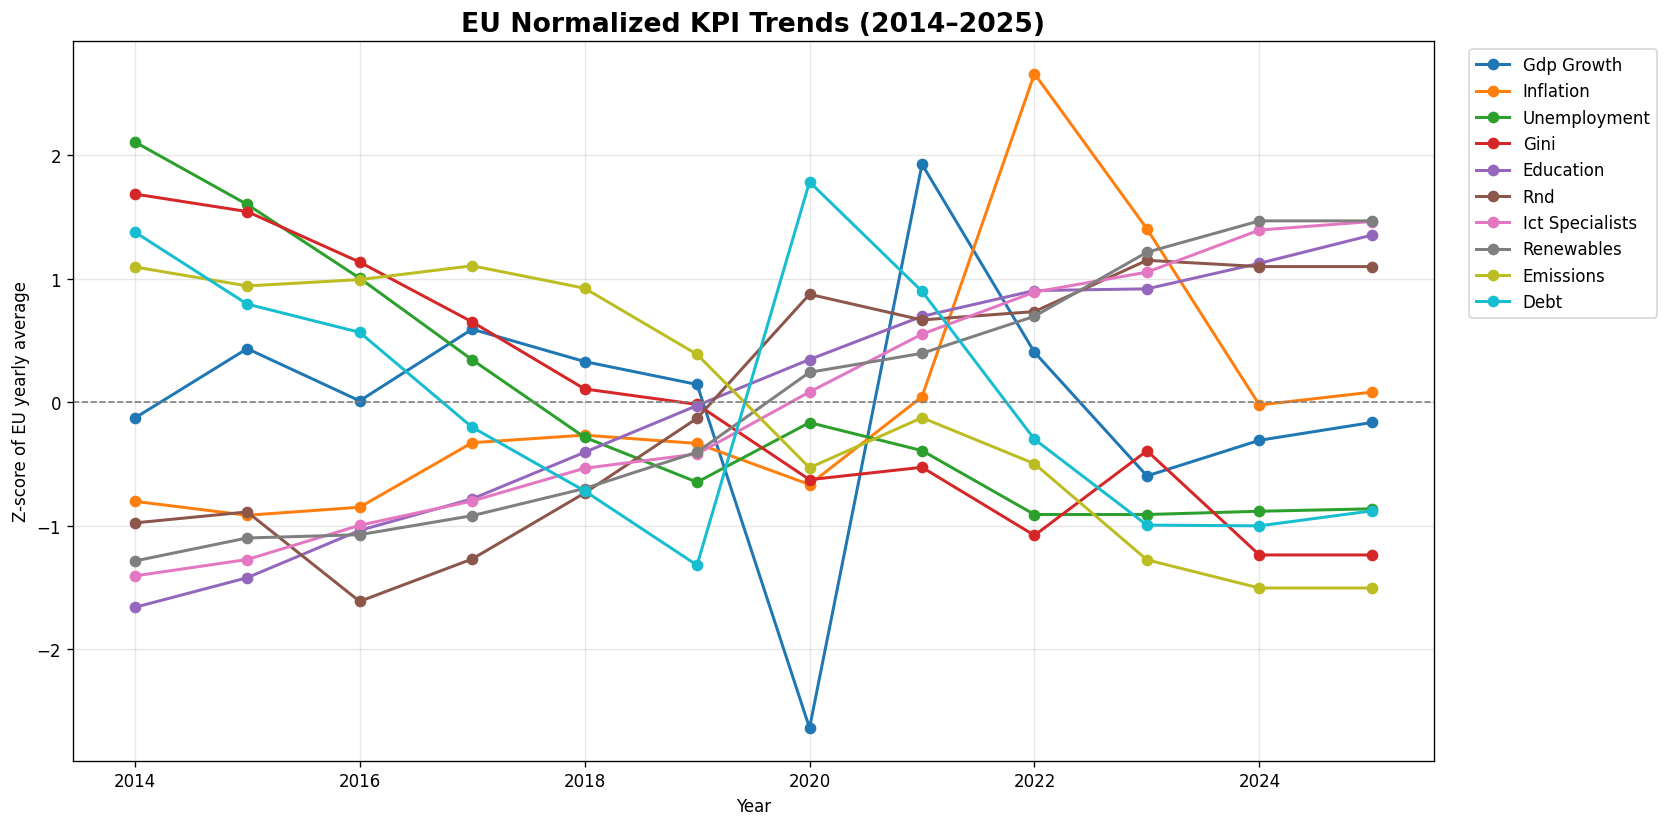

In [4]:
from sklearn.preprocessing import StandardScaler

kpis = [
    "gdp_growth",
    "inflation",
    "unemployment",
    "gini",
    "education",
    "rnd",
    "ict_specialists",
    "renewables",
    "emissions",
    "debt",
]

# EU yearly average
kpi_trends = eu_master_plus.groupby("year")[kpis].mean()

# Normalize each KPI trend so changes are comparable on one chart
scaler = StandardScaler()
kpi_trends_scaled = pd.DataFrame(
    scaler.fit_transform(kpi_trends),
    columns=kpis,
    index=kpi_trends.index,
)

plt.figure(figsize=(14, 7))

for col in kpis:
    plt.plot(
        kpi_trends_scaled.index,
        kpi_trends_scaled[col],
        marker="o",
        linewidth=1.8,
        label=col.replace("_", " ").title(),
    )

plt.axhline(0, linestyle="--", linewidth=1, color="gray")
plt.title("EU Normalized KPI Trends (2014–2025)", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Z-score of EU yearly average")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_1_eu_normalized_kpi_trends.png", bbox_inches="tight")
plt.show()

## Figure 2 — Relative Structural Trajectories of Selected European Countries

Normalized country trajectories relative to the EU distribution, illustrating distinct structural pathways and emerging country archetypes.

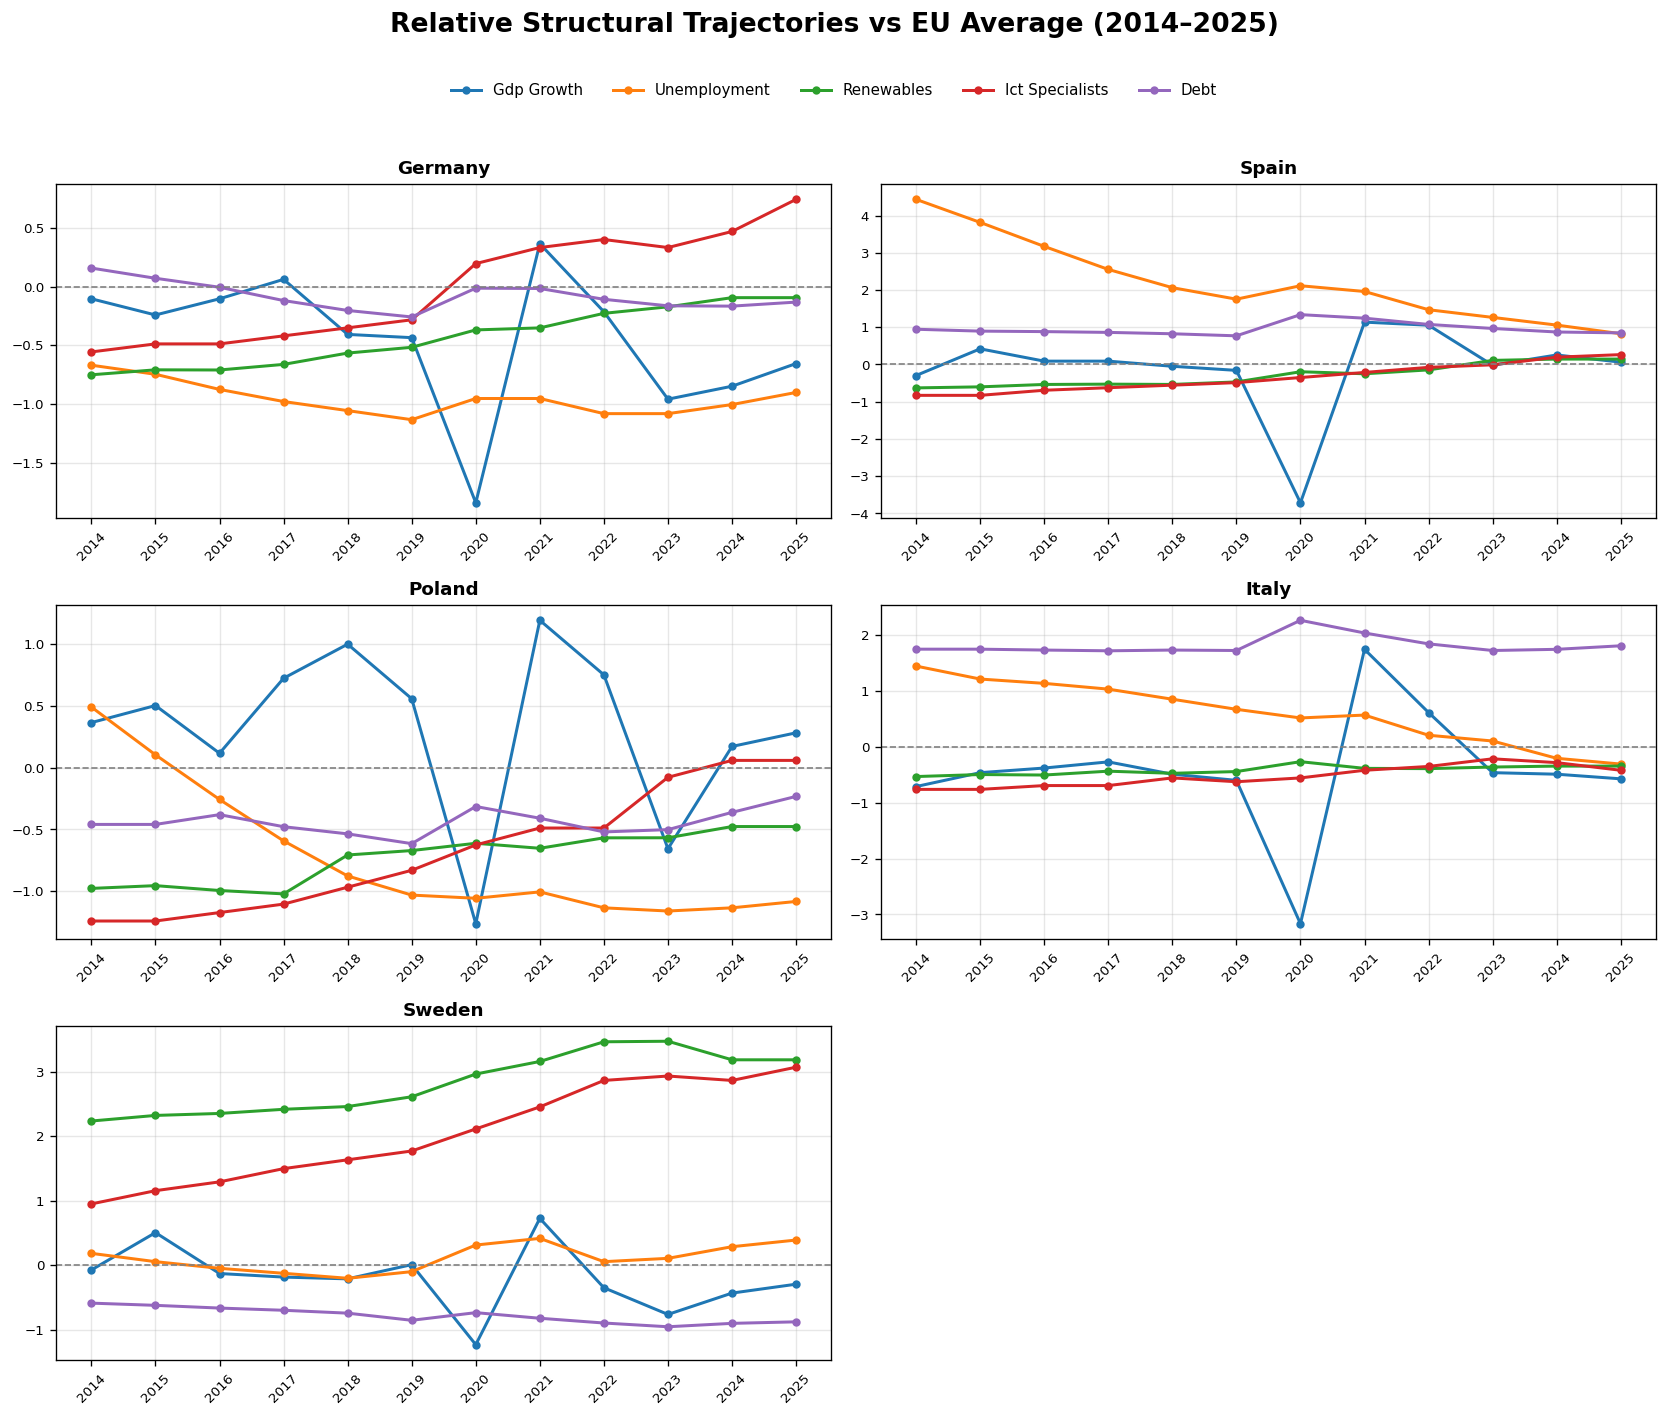

In [5]:
from sklearn.preprocessing import StandardScaler

countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden",
}

trajectory_kpis = [
    "gdp_growth",
    "unemployment",
    "renewables",
    "ict_specialists",
    "debt",
]

# Fit scaler on all EU country-year values
scaler = StandardScaler()
scaler.fit(eu_master_plus[trajectory_kpis])

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12),
    sharex=False,
)

axes = axes.flatten()

for i, (code, name) in enumerate(countries.items()):
    ax = axes[i]

    temp = (
        eu_master_plus[eu_master_plus["country"] == code]
        .sort_values("year")
        .copy()
    )

    temp_scaled = pd.DataFrame(
        scaler.transform(temp[trajectory_kpis]),
        columns=trajectory_kpis,
        index=temp["year"],
    )

    for kpi in trajectory_kpis:
        ax.plot(
            temp_scaled.index,
            temp_scaled[kpi],
            marker="o",
            linewidth=1.8,
            markersize=4,
            label=kpi.replace("_", " ").title(),
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xticks(temp_scaled.index)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[-1])

fig.suptitle(
    "Relative Structural Trajectories vs EU Average (2014–2025)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=5,
    fontsize=9,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIGURES_DIR / "figure_2_relative_country_trajectories.png", bbox_inches="tight")
plt.show()

## Figure 3 — Government Spending Priorities Relative to EU Average

EU-relative public expenditure trajectories across selected European countries, highlighting differences in welfare, sustainability, innovation, economic development, and resilience-oriented policy priorities between 2014–2025.

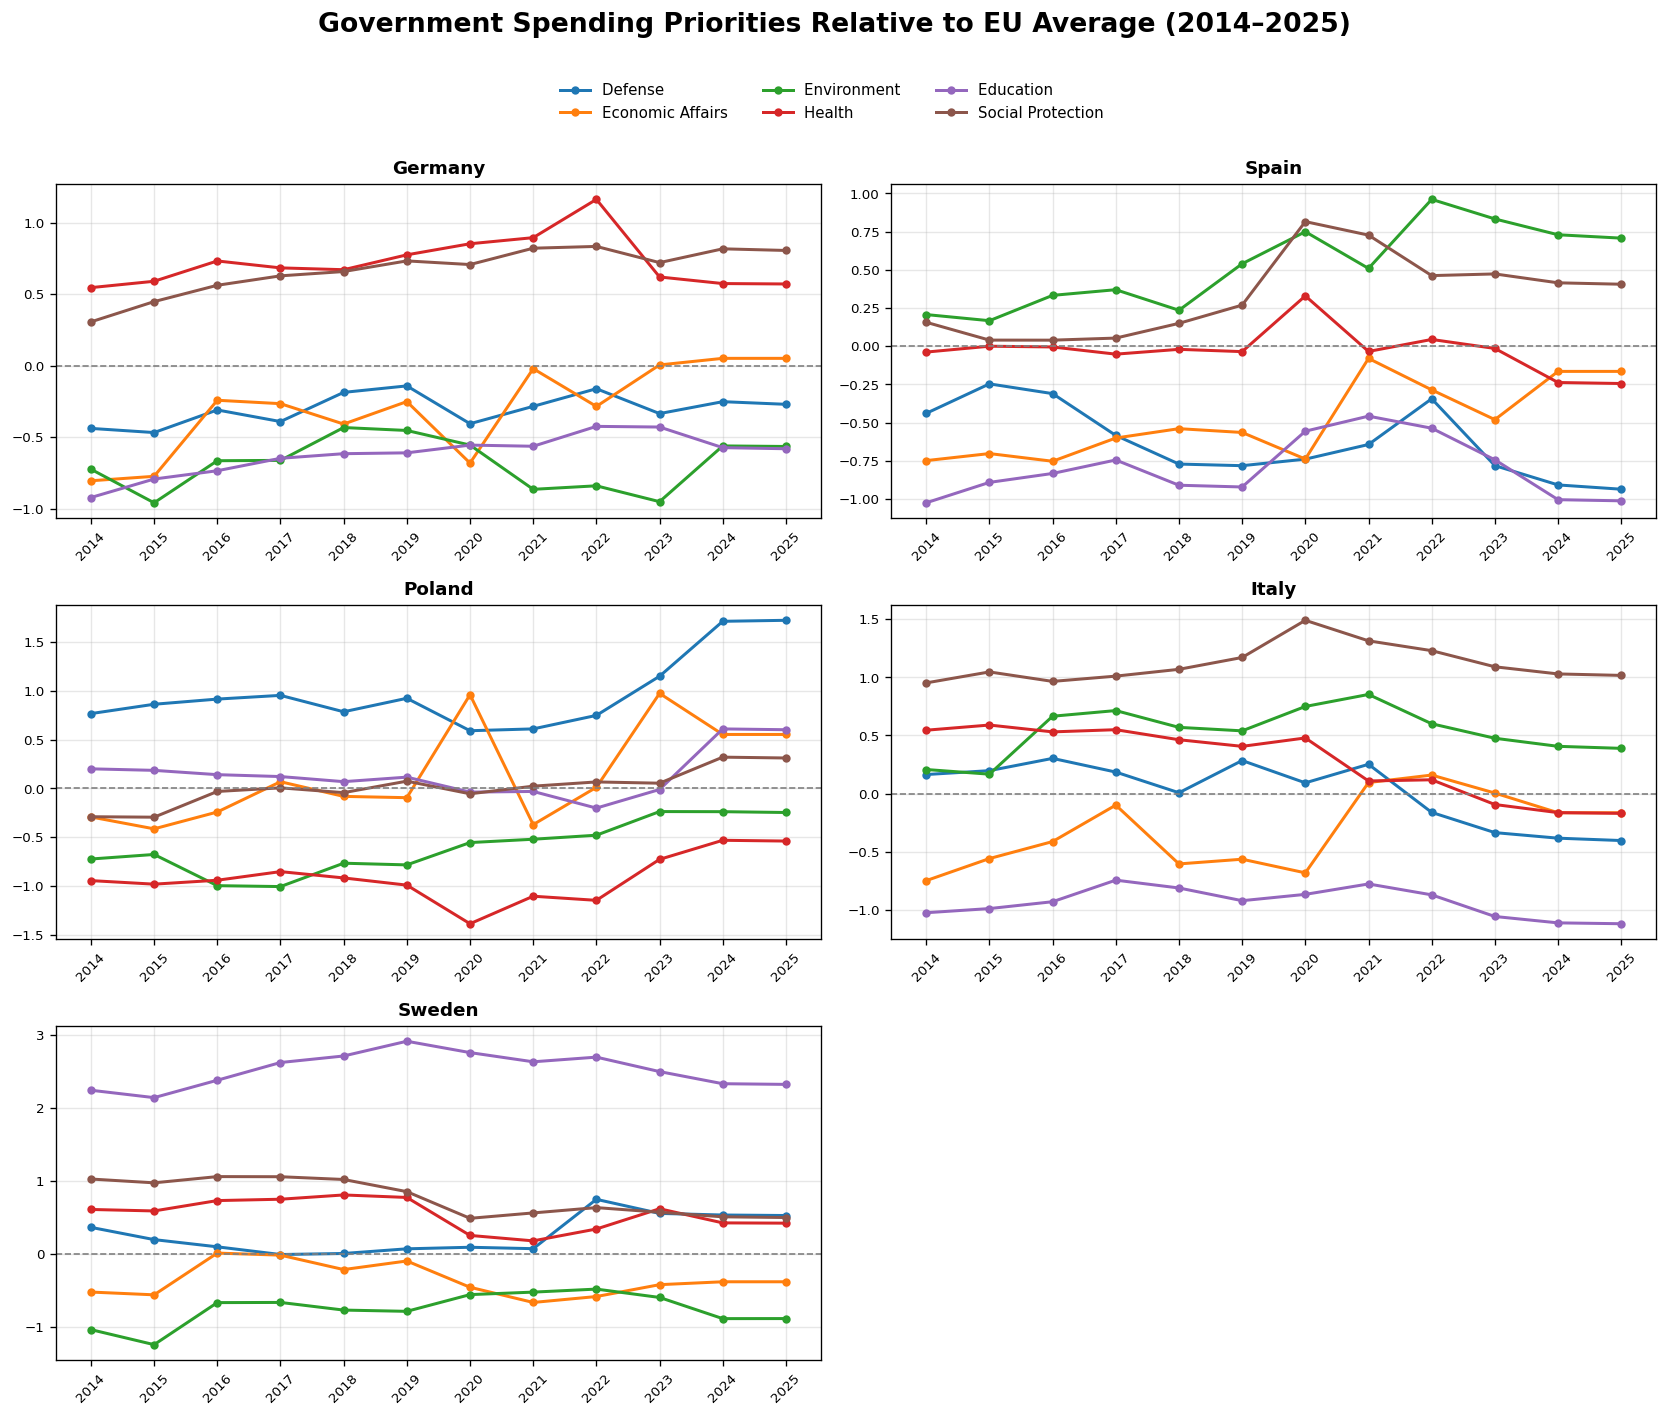

In [6]:
from scipy.stats import zscore

spending_cols = [
    "defense_spending",
    "economic_affairs_spending",
    "environment_spending",
    "health_spending",
    "education_spending",
    "social_protection_spending",
]

# Keep only spending columns that exist in the processed file
spending_cols = [col for col in spending_cols if col in eu_master_plus.columns]

eu_relative = eu_master_plus.copy()

# Normalize each spending category relative to EU distribution per year
for col in spending_cols:
    eu_relative[f"{col}_z"] = (
        eu_relative
        .groupby("year")[col]
        .transform(lambda x: zscore(x, nan_policy="omit"))
    )

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12),
    sharex=False,
)

axes = axes.flatten()

for i, (code, name) in enumerate(countries.items()):
    ax = axes[i]

    country_df = (
        eu_relative[eu_relative["country"] == code]
        .sort_values("year")
    )

    for col in spending_cols:
        ax.plot(
            country_df["year"],
            country_df[f"{col}_z"],
            marker="o",
            linewidth=1.8,
            markersize=4,
            label=col.replace("_", " ").replace("spending", "").title(),
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xticks(country_df["year"])
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(alpha=0.3)

fig.delaxes(axes[-1])

fig.suptitle(
    "Government Spending Priorities Relative to EU Average (2014–2025)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    fontsize=9,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIGURES_DIR / "figure_3_spending_relative_to_eu.png", bbox_inches="tight")
plt.show()

## Germany — Correlation Heatmap

Exploratory correlations only. With 12 years of data, correlations may partly reflect shared time trends rather than causal relationships.

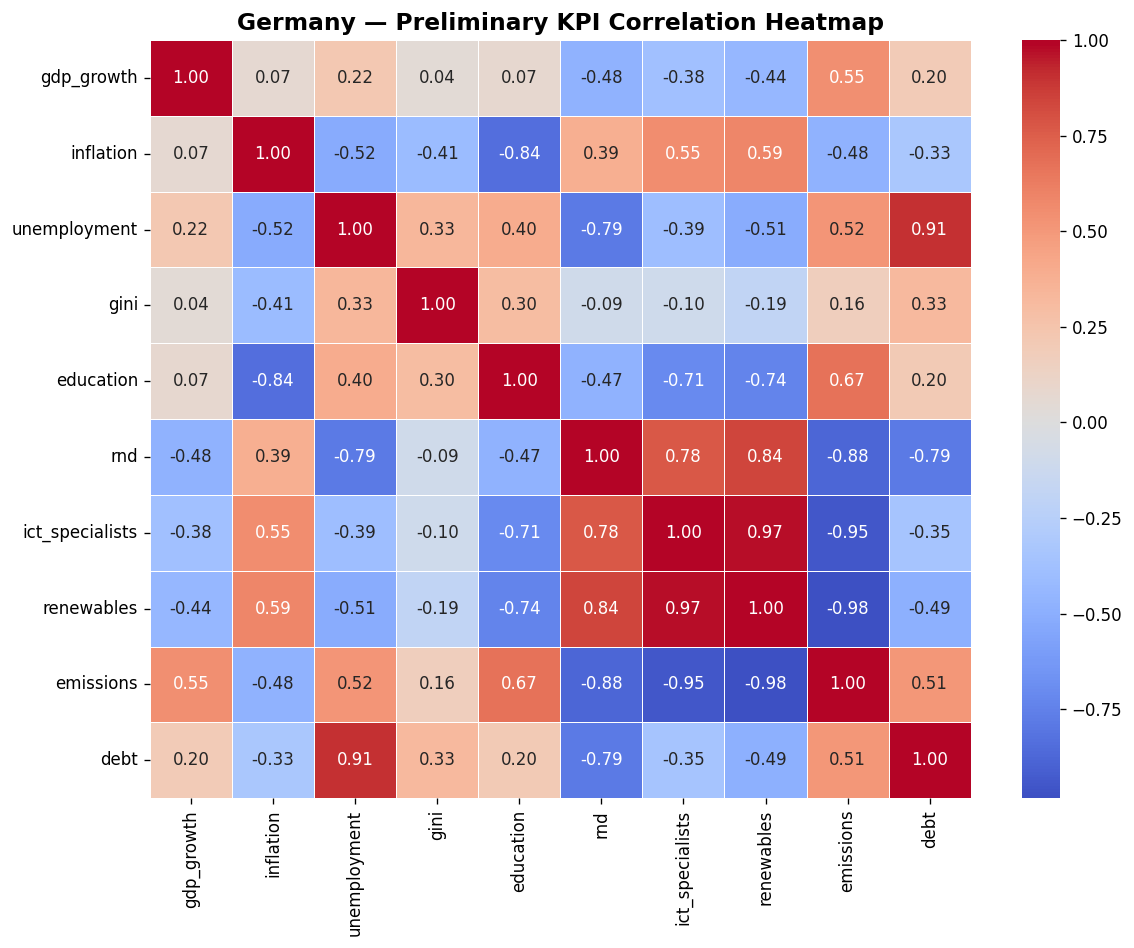

In [7]:
import seaborn as sns

germany = (
    eu_master_plus[eu_master_plus["country"] == "DE"]
    .sort_values("year")
)

corr_cols = [
    "gdp_growth",
    "inflation",
    "unemployment",
    "gini",
    "education",
    "rnd",
    "ict_specialists",
    "renewables",
    "emissions",
    "debt",
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    germany[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Germany — Preliminary KPI Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "germany_kpi_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Germany — Energy Transition Trajectory

A simple tradeoff trajectory: renewables vs emissions over time.

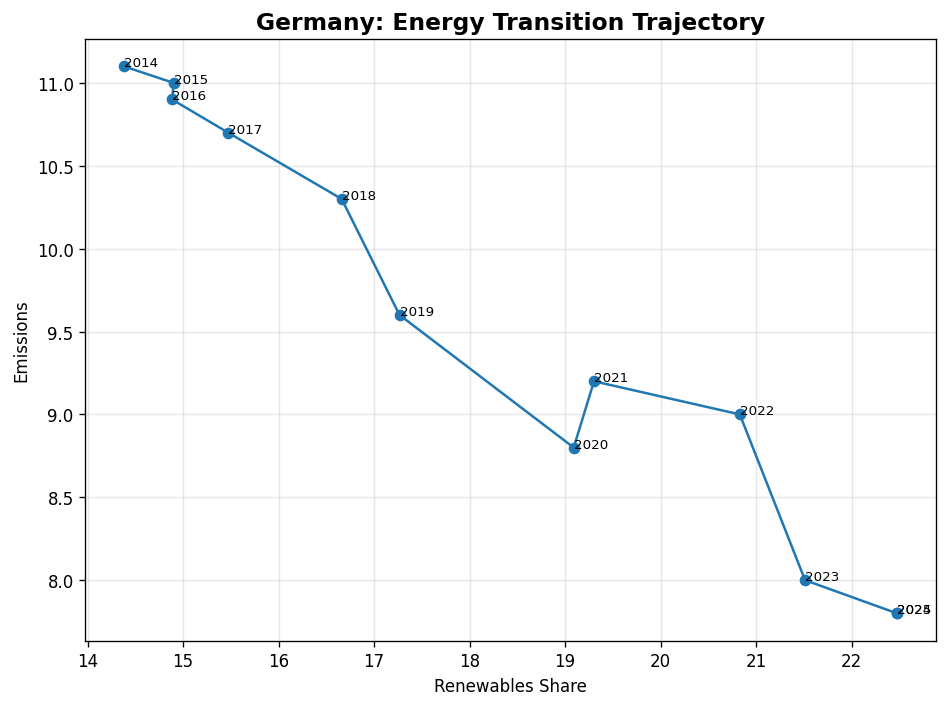

In [8]:
plt.figure(figsize=(8, 6))

plt.plot(
    germany["renewables"],
    germany["emissions"],
    marker="o",
)

for i, year in enumerate(germany["year"]):
    plt.text(
        germany["renewables"].iloc[i],
        germany["emissions"].iloc[i],
        str(year),
        fontsize=8,
    )

plt.xlabel("Renewables Share")
plt.ylabel("Emissions")
plt.title("Germany: Energy Transition Trajectory", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "germany_energy_transition_trajectory.png", bbox_inches="tight")
plt.show()

## Save EDA-Ready Tableau Extract

This is the main CSV Tableau should connect to.

In [9]:
tableau_export = PROCESSED_DIR / "tableau_eu_master_plus.csv"
eu_master_plus.to_csv(tableau_export, index=False)
print("Saved:", tableau_export)

Saved: C:\Users\gilad\Documents\Data Analytics course 02_26\capstone-eu-structural-tradeoffs\data\processed\tableau_eu_master_plus.csv
